# Software dependencies for shallow net in Keras

In [76]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import SGD
from matplotlib import pyplot as plt

 # Loading MNIST data

In [77]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [78]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

# MNIST data printing

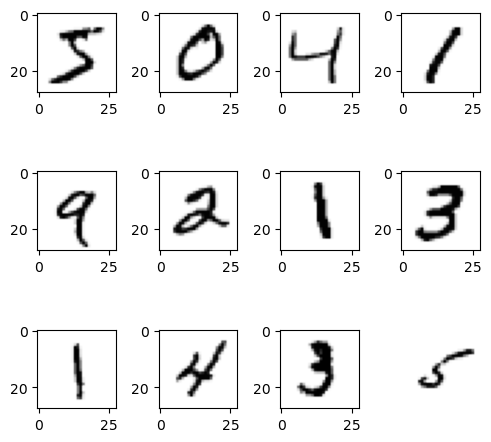

In [79]:
plt.figure(figsize=(5,5))
for k in range(12):
    plt.subplot(3, 4, k+1)
    plt.imshow(X_train[k], cmap='Greys')
plt.axis('off')
plt.tight_layout()
plt.show()

# Reformatting the Data

In [80]:
# Flattening two-dimensional images to one dimension
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [81]:
# Converting integer labels to one-hot
n_classes = 10
y_train = keras.utils.to_categorical(y_train, n_classes)
y_test = keras.utils.to_categorical(y_test, n_classes)
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

# Designing a Neural Network Architecture

In [82]:
# Keras code to architect a shallow neural network
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [83]:
# Keras code to compile our intermediate-depth neural network
model.compile(loss='categorical_crossentropy',optimizer=keras.optimizers.legacy.SGD(learning_rate=0.1),metrics=['accuracy'])

In [84]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_6 (Flatten)         (None, 784)               0         
                                                                 
 dense_19 (Dense)            (None, 64)                50240     
                                                                 
 dense_20 (Dense)            (None, 10)                650       
                                                                 
Total params: 50890 (198.79 KB)
Trainable params: 50890 (198.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Training a Deep Learning Model

In [85]:
# Keras code to train our shallow neural network
model.fit(X_train,y_train,batch_size=128,epochs=15,verbose=1,validation_data=(X_test, y_test))

Epoch 1/15
  7/469 [..............................] - ETA: 4s - loss: 2.0497 - accuracy: 0.3248  

2025-04-10 15:55:23.096900: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


469/469 [==============================] - ETA: 0s - loss: 0.4920 - accuracy: 0.8654

2025-04-10 15:55:27.581670: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


469/469 [==============================] - 5s 11ms/step - loss: 0.4920 - accuracy: 0.8654 - val_loss: 0.3178 - val_accuracy: 0.9102
Epoch 2/15
469/469 [==============================] - 5s 11ms/step - loss: 0.3220 - accuracy: 0.9083 - val_loss: 0.2934 - val_accuracy: 0.9183
Epoch 3/15
469/469 [==============================] - 5s 11ms/step - loss: 0.3036 - accuracy: 0.9141 - val_loss: 0.2864 - val_accuracy: 0.9203
Epoch 4/15
469/469 [==============================] - 5s 11ms/step - loss: 0.2946 - accuracy: 0.9173 - val_loss: 0.2886 - val_accuracy: 0.9195
Epoch 5/15
469/469 [==============================] - 5s 11ms/step - loss: 0.2895 - accuracy: 0.9191 - val_loss: 0.2817 - val_accuracy: 0.9211
Epoch 6/15
469/469 [==============================] - 5s 11ms/step - loss: 0.2851 - accuracy: 0.9198 - val_loss: 0.2861 - val_accuracy: 0.9197
Epoch 7/15
469/469 [==============================] - 5s 11ms/step - loss: 0.2838 - accuracy: 0.9215 - val_loss: 0.2855 - val_accuracy: 0.9198
Epoch 8/15

In [87]:
loss, accuracy = model.evaluate(X_test,y_test, verbose=0)
print("Test Accuracy:",accuracy)
print("Test Loss:",loss)

Test Accuracy: 0.9125999808311462
Test Loss: 0.3179057836532593
